# EDA

## Loading Data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('../data/raw_data/customer_support_dataset.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

(26872, 5)
flags          str
instruction    str
category       str
intent         str
response       str
dtype: object
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64
Duplicates: 0


In [13]:
df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


## Category Distribution

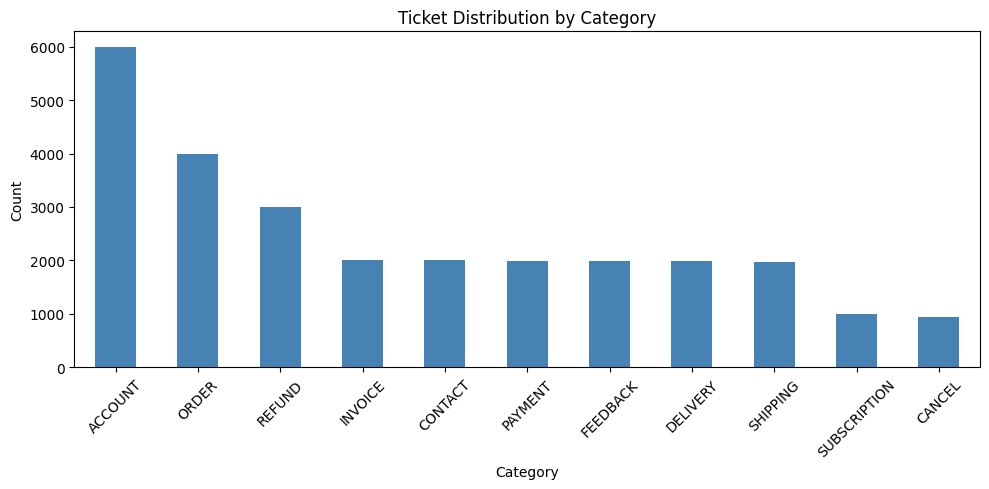

In [ ]:
plt.figure(figsize=(10, 5))
df['category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Ticket Distribution by Category')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45); plt.tight_layout()
plt.show()


## Intent Distribution

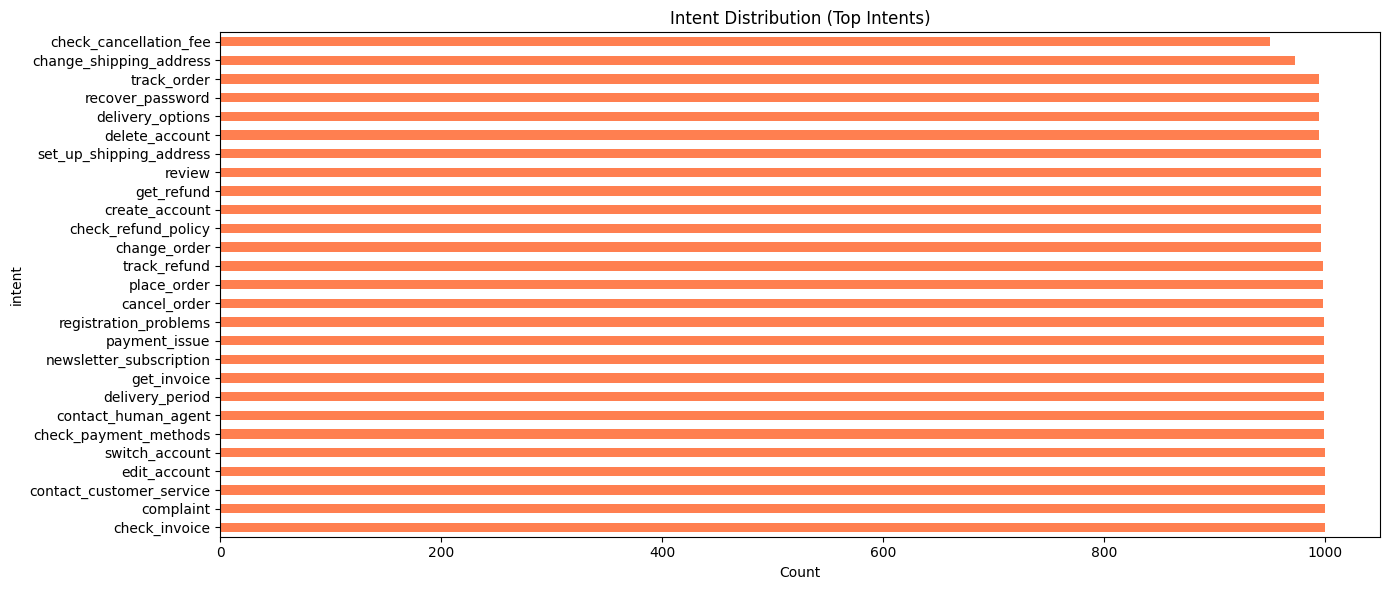

In [ ]:

plt.figure(figsize=(14, 6))
df['intent'].value_counts().plot(kind='barh', color='coral')
plt.title('Intent Distribution (Top Intents)')
plt.xlabel('Count'); plt.tight_layout()
plt.show()


### **Category vs Intent**



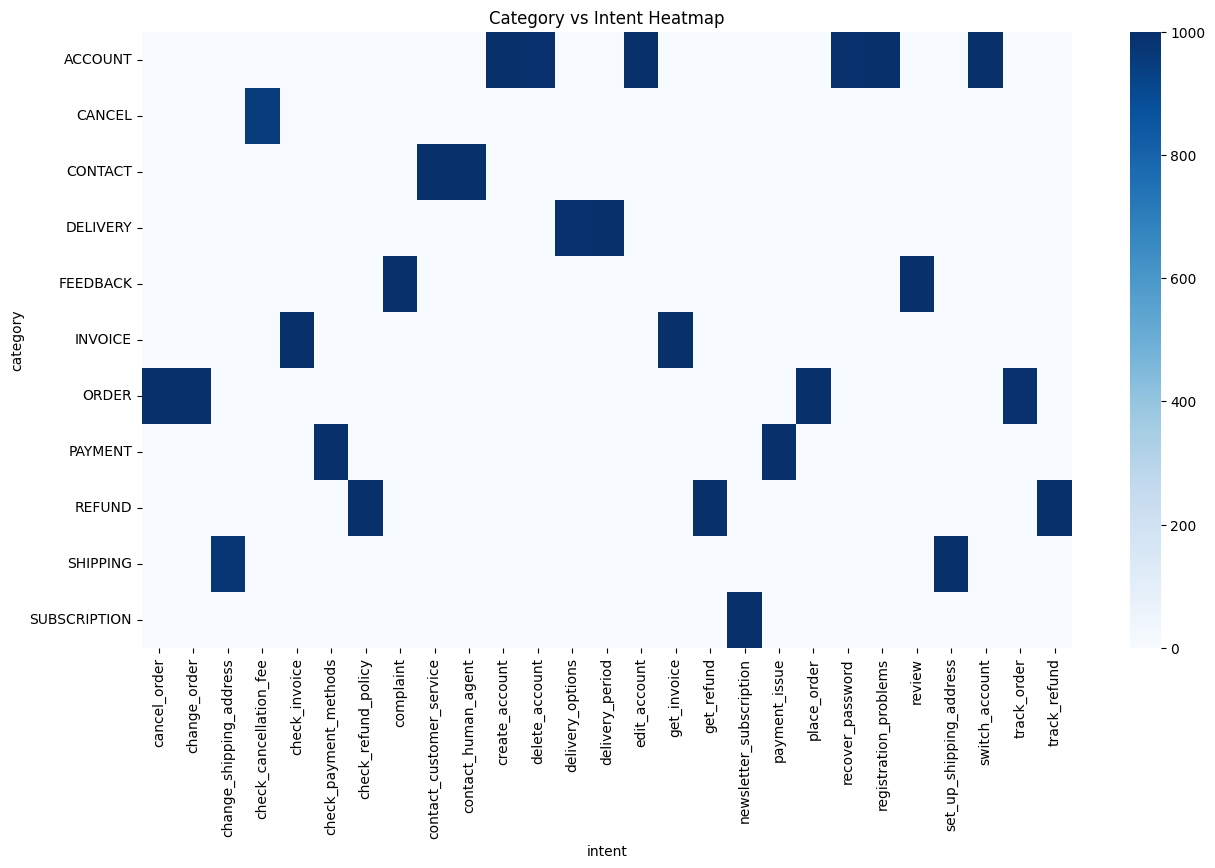

In [14]:
cross_tab = pd.crosstab(df['category'], df['intent'])

plt.figure(figsize=(15,8))
sns.heatmap(cross_tab, cmap="Blues")
plt.title("Category vs Intent Heatmap")
plt.show()

## Text Length Analysis

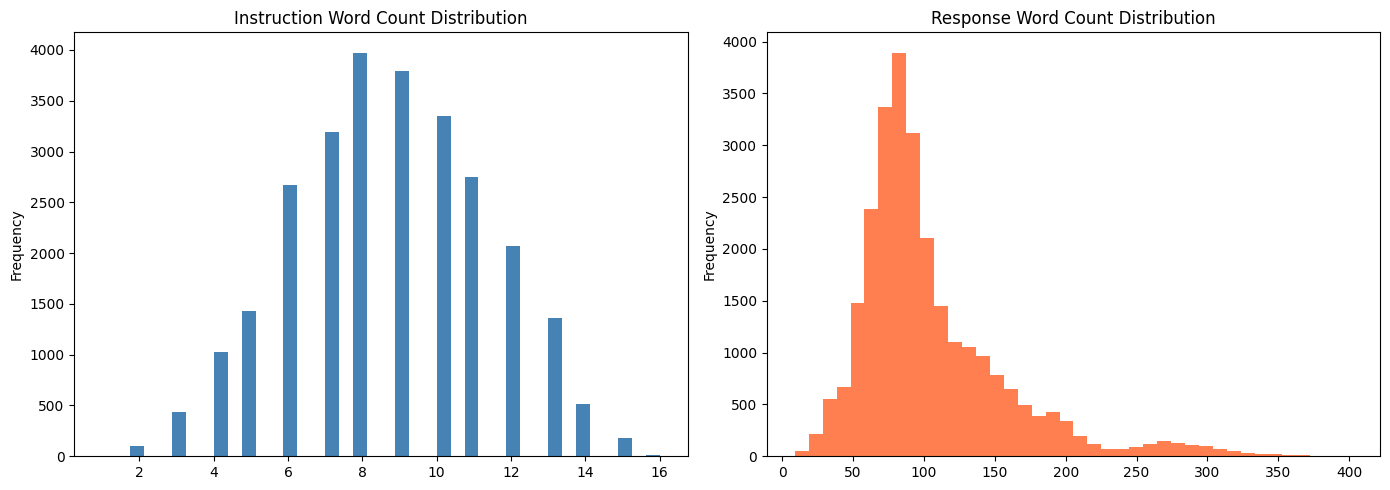

       instruction_len  response_len
count     26872.000000  26872.000000
mean          8.690979    104.789037
std           2.605004     52.966204
min           1.000000      9.000000
25%           7.000000     72.000000
50%           9.000000     90.000000
75%          11.000000    124.000000
max          16.000000    402.000000


In [ ]:

df['instruction_len'] = df['instruction'].apply(lambda x: len(str(x).split()))
df['response_len']    = df['response'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['instruction_len'].plot(kind='hist', bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Instruction Word Count Distribution')
df['response_len'].plot(kind='hist', bins=40, ax=axes[1], color='coral')
axes[1].set_title('Response Word Count Distribution')
plt.tight_layout()
plt.show()

print(df[['instruction_len','response_len']].describe())


### Most Common Words in Queries

In [16]:
def clean_text_basic(text):
    text = text.lower()
    text = re.sub(r'\{\{.*?\}\}', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_instruction'] = df['instruction'].apply(clean_text_basic)
all_words = " ".join(df['clean_instruction']).split()
word_counts = Counter(all_words)

print("Top 20 Most Common Words:")
print(word_counts.most_common(20))

Top 20 Most Common Words:
[('i', 18874), ('to', 16400), ('the', 6413), ('help', 6319), ('a', 6086), ('do', 5348), ('can', 5274), ('my', 4774), ('how', 4207), ('need', 4059), ('of', 3995), ('me', 3661), ('account', 3567), ('what', 3136), ('want', 3110), ('assistance', 3005), ('have', 2957), ('know', 2691), ('with', 2553), ('see', 2545)]


In [17]:
print("Top 10 Repeated Instructions:")
print(df['instruction'].value_counts().head(10))

Top 10 Repeated Instructions:
instruction
do you ship to {{Delivery City}}?                           8
shipments to {{Delivery City}}                              8
is it possible to order from {{Delivery City}}?             8
do you deliver to {{Delivery City}} ?                       8
is it possible to order from {{Delivery City}} ?            8
is it possible to place an order from {{Delivery City}}?    8
can I place an order from {{Delivery City}}?                8
shipmetns to {{Delivery City}}                              8
d uship to {{Delivery City}}                                8
shiping to {{Delivery City}}                                8
Name: count, dtype: int64


## Flags

### The flags column contains Language Generation Tags — single-letter codes that describe the linguistic style of each customer instruction, not the topic. They help train chatbots to handle different types of real-world language.

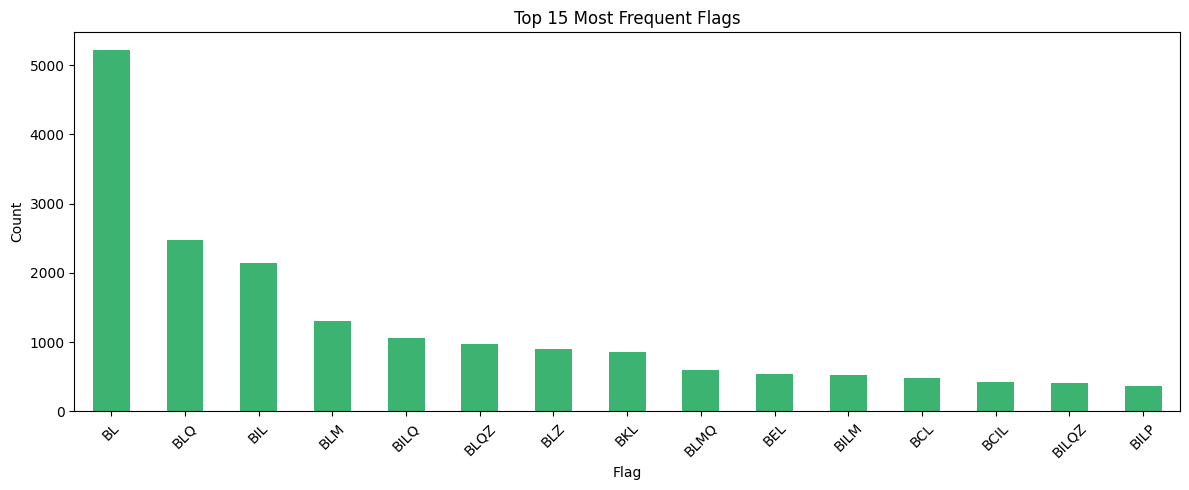

In [ ]:

top_flags = df['flags'].value_counts().head(15)
plt.figure(figsize=(12, 5))
top_flags.plot(kind='bar', color='mediumseagreen')
plt.title('Top 15 Most Frequent Flags')
plt.xlabel('Flag'); plt.ylabel('Count')
plt.xticks(rotation=45); plt.tight_layout()
plt.show()


## TEMPLATE VARIABLE DETECTION 

### This analysis is important for your RAG chatbot because:

High {{ rate → you'll need an entity extraction step to fill those slots at inference time

Knowing which variables appear most → tells you which backend data (orders, accounts, invoices) your API integration in Milestone 3 must connect to

Cleaning decision → you may want to either replace {{Order Number}} with a generic token like [ORDER_ID] or strip it entirely during preprocessing

In [ ]:
# Instructions contain placeholders like {{Order Number}}
df['has_template_var'] = df['instruction'].str.contains(r'\{\{', na=False)
print("Instructions with template variables:")
print(df['has_template_var'].value_counts())

# Extract all unique template variable types
all_vars = re.findall(r'\{\{(.*?)\}\}', ' '.join(df['instruction'].astype(str)))
print("\nTop template variable types:")
print(Counter(all_vars).most_common(10))


Instructions with template variables:
has_template_var
False    20202
True      6670
Name: count, dtype: int64

Top template variable types:
[('Order Number', 2907), ('Account Type', 1011), ('Person Name', 887), ('Account Category', 822), ('Refund Amount', 624), ('Currency Symbol', 372), ('Delivery City', 234), ('Delivery Country', 177), ('Invoice Number', 8)]


## Summary Stats

In [ ]:

print("=== EDA SUMMARY ===")
print(f"Total records       : {len(df)}")
print(f"Unique categories   : {df['category'].nunique()}")
print(f"Unique intents      : {df['intent'].nunique()}")
print(f"Unique flags        : {df['flags'].nunique()}")
print(f"Avg instruction len : {df['instruction_len'].mean():.1f} words")
print(f"Avg response len    : {df['response_len'].mean():.1f} words")
print(f"Missing values      : {df.isnull().sum().sum()}")
print(f"Duplicate rows      : {df.duplicated().sum()}")


=== EDA SUMMARY ===
Total records       : 26872
Unique categories   : 11
Unique intents      : 27
Unique flags        : 394
Avg instruction len : 8.7 words
Avg response len    : 104.8 words
Missing values      : 0
Duplicate rows      : 0


## EDA Findings
Size: 26,872 rows, 5 columns (flags, instruction, category, intent, response).

Completeness: No missing values; all columns are fully populated with non‑null strings.

Data Quality: No empty strings in instruction or response. No exact duplicate rows across all columns.

Common Queries and Topics "ETA of order {{Order Number}}"

"I am trying to cancel order {{Order Number}}"

"I am trying to change to the {{Account Type}}"

"I am trying to download the bill"

"I am waiting for a compensation"

Topic Distribution
ACCOUNT (~6,000)

ORDER (~5,000)

REFUND (~3,000)

CONTACT (~2,500)

INVOICE (~2,000)

PAYMENT (~1,500)

FEEDBACK (~1,000)

DELIVERY (~800)

SHIPPING (~600)

SUBSCRIPTION (~400)

CANCEL (~200)

Category vs Intent Relationship
ORDER category is strongly associated with intents like cancel_order, track_order, change_order, place_order.

ACCOUNT category aligns with create_account, delete_account, edit_account, switch_account, recover_password.

REFUND maps to get_refund, track_return.

INVOICE to get_invoice, check_invoice.

PAYMENT to payment_intent, check_payment_methods.

CONTACT to contact_customer_service, contact_human_agent, complaint.

DELIVERY/SHIPPING to delivery_period, delivery_options, set_up_shipment_address, track_order (overlap with ORDER).

FEEDBACK to review.

SUBSCRIPTION to newsletter_subscription.

CANCEL likely overlaps with ORDER and REFUND.